# In-Class Assignment 05/28/2026

## Name: Christine Wu

### Importing libraries

In [1]:
# Libraries

import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Load & inspect data

In [2]:
# Load and inspect Bitcoin data

bitcoin = pd.read_csv("dc.csv")

bitcoin = bitcoin.rename(
    columns={"Unnamed: 0": "date"}
)

bitcoin["date"] = pd.to_datetime(bitcoin["date"])

bitcoin = (
    bitcoin
    .sort_values("date")
    .reset_index(drop=True)
)

print(bitcoin.shape)

bitcoin.head()

(1000, 6)


,date,open_USD,high_USD,low_USD,close_USD,volume
0,2018-05-07,9661.02,9689.67,9181.00,9365.00,33787
1,2018-05-08,9365.00,9475.70,9060.54,9187.56,25533
2,2018-05-09,9178.00,9390.00,8965.00,9310.00,25673
3,2018-05-10,9310.00,9395.12,8970.00,9002.20,25055
4,2018-05-11,9002.21,9016.80,8341.00,8400.00,48227


In [3]:
# Basic inspection

bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       1000 non-null   datetime64[ns]
 1   open_USD   1000 non-null   float64       
 2   high_USD   1000 non-null   float64       
 3   low_USD    1000 non-null   float64       
 4   close_USD  1000 non-null   float64       
 5   volume     1000 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 47.0 KB


In [4]:
# Summary statistics

bitcoin.describe()

,date,open_USD,high_USD,low_USD,close_USD,volume
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2019-09-18 12:00:00,9285.762120,9542.880270,9011.393200,9310.335850,53100.498000
min,2018-05-07 00:00:00,3211.710000,3276.500000,3156.260000,3211.720000,5743.000000
25%,2019-01-11 18:00:00,6467.192500,6582.255000,6325.015000,6466.762500,30045.750000
50%,2019-09-18 12:00:00,8189.695000,8351.630000,8002.045000,8189.330000,43795.500000
75%,2020-05-25 06:00:00,10216.860000,10419.562500,9907.977500,10220.170000,64909.250000
max,2021-01-30 00:00:00,40586.960000,41950.000000,38720.000000,40582.810000,402201.000000
std,NaN,5793.522832,6075.604427,5483.524463,5846.917681,35329.832031


Visualizing the target variable

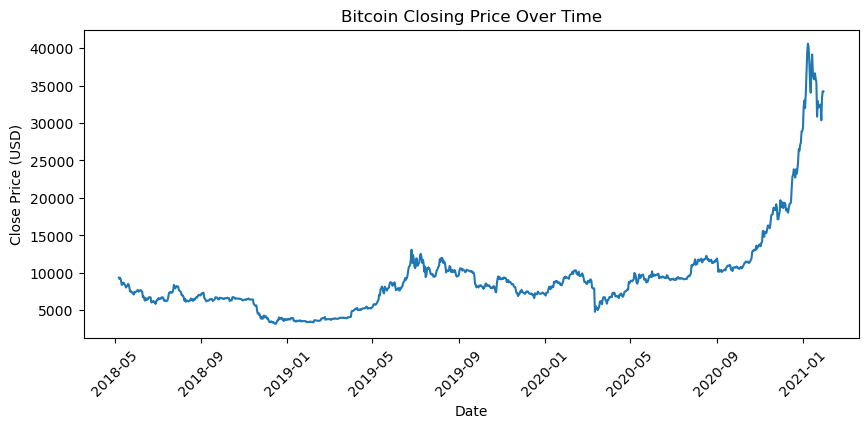

In [5]:
# Visualize closing price over time

plt.figure(figsize=(10, 4))

plt.plot(
    bitcoin["date"],
    bitcoin["close_USD"]
)

plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.xticks(rotation=45)

plt.show()

### Preparing data for recurrent modeling

In [6]:
# Prepare Bitcoin data for recurrent models

features = [
    "open_USD",
    "high_USD",
    "low_USD",
    "close_USD",
    "volume"
]

target_col = "close_USD"

bitcoin_model = bitcoin[["date"] + features].copy()

print("Unique dates:", bitcoin_model["date"].nunique())
print("Rows:", len(bitcoin_model))

scaler_bitcoin = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler_bitcoin.fit_transform(
    bitcoin_model[features]
)

look_back = 10                                                  # use 10 previous days to predict next close

target_index = features.index(target_col)

Unique dates: 1000
Rows: 1000


### Useful functions

In [7]:
# Function to create recurrent sequence windows

def create_sequences(dataset, target_index, look_back=10):

    X, y = [], []

    for i in range(len(dataset) - look_back):

        X.append(
            dataset[i:i + look_back, :]
        )                                                       # previous look_back days

        y.append(
            dataset[i + look_back, target_index]
        )                                                       # next day's close_USD

    return np.array(X), np.array(y)

In [8]:
# Function to visualize training curves

def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(
        history.history["loss"],
        label="Training Loss"
    )

    axes[0].plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")

    axes[0].legend()

    # MAE
    axes[1].plot(
        history.history["mean_absolute_error"],
        label="Training MAE"
    )

    axes[1].plot(
        history.history["val_mean_absolute_error"],
        label="Validation MAE"
    )

    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")

    axes[1].legend()

    plt.tight_layout()

    plt.show()

In [9]:
# Function to evaluate forecasting performance

def evaluate_and_plot(
    model,
    trainX,
    testX,
    trainY,
    testY,
    scaler,
    target_index,
    title
):

    # Predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Create arrays for inverse scaling
    train_dummy = np.zeros((len(train_pred), len(features)))
    test_dummy = np.zeros((len(test_pred), len(features)))

    train_dummy[:, target_index] = train_pred.flatten()
    test_dummy[:, target_index] = test_pred.flatten()

    trainY_dummy = np.zeros((len(trainY), len(features)))
    testY_dummy = np.zeros((len(testY), len(features)))

    trainY_dummy[:, target_index] = trainY
    testY_dummy[:, target_index] = testY

    # Inverse transform
    train_pred_inv = scaler.inverse_transform(train_dummy)[:, target_index]
    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]

    trainY_inv = scaler.inverse_transform(trainY_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    train_mae = mean_absolute_error(trainY_inv, train_pred_inv)
    test_mae = mean_absolute_error(testY_inv, test_pred_inv)

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    print(f"{title} Train MAE: {train_mae:.2f}")
    print(f"{title} Test MAE: {test_mae:.2f}")

    # Plot predictions
    plt.figure(figsize=(10, 4))

    plt.plot(
        testY_inv,
        label="Actual"
    )

    plt.plot(
        test_pred_inv,
        label="Predicted"
    )

    plt.title(title + " Test Predictions")

    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(
        style="plain",
        axis="y"
    )

    plt.legend()

    plt.show()

In [10]:
# Function to compare model metrics

def evaluate_metrics(
    model,
    testX,
    testY,
    scaler,
    target_index
):

    test_pred = model.predict(testX)

    test_dummy = np.zeros((len(test_pred), len(features)))
    test_dummy[:, target_index] = test_pred.flatten()

    testY_dummy = np.zeros((len(testY), len(features)))
    testY_dummy[:, target_index] = testY

    test_pred_inv = scaler.inverse_transform(test_dummy)[:, target_index]
    testY_inv = scaler.inverse_transform(testY_dummy)[:, target_index]

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

### Creating train/test recurrent tensors

In [11]:
# Create train/test recurrent tensors

train_size = int(len(scaled_features) * 0.8)                    # chronological 80/20 split

train_bitcoin = scaled_features[:train_size]                    # earlier data
test_bitcoin = scaled_features[train_size:]                     # held-out future data

trainX_bitcoin, trainY_bitcoin = create_sequences(
    train_bitcoin,
    target_index,
    look_back
)

testX_bitcoin, testY_bitcoin = create_sequences(
    test_bitcoin,
    target_index,
    look_back
)

print("trainX_bitcoin shape:", trainX_bitcoin.shape)
print("testX_bitcoin shape:", testX_bitcoin.shape)
print("trainY_bitcoin shape:", trainY_bitcoin.shape)
print("testY_bitcoin shape:", testY_bitcoin.shape)

trainX_bitcoin shape: (790, 10, 5)
testX_bitcoin shape: (190, 10, 5)
trainY_bitcoin shape: (790,)
testY_bitcoin shape: (190,)


### Baseline SimpleRNN model

In [12]:
# Build and train baseline SimpleRNN model

simple_rnn_model = Sequential([
    SimpleRNN(
        8,                                     # small baseline recurrent layer
        activation="tanh",                     # standard activation for SimpleRNN
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

simple_rnn_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

simple_rnn_history = simple_rnn_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 1/40 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.0463 - mean_absolute_error: 0.2108


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0108 - mean_absolute_error: 0.0820 - val_loss: 0.0113 - val_mean_absolute_error: 0.0747


Epoch 2/50


...


 1/40 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.6795e-04 - mean_absolute_error: 0.0112


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2417e-04 - mean_absolute_error: 0.0080 - val_loss: 1.8307e-04 - val_mean_absolute_error: 0.0092


Epoch 50/50



 1/40 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.6691e-04 - mean_absolute_error: 0.0111


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2341e-04 - mean_absolute_error: 0.0079 - val_loss: 1.8160e-04 - val_mean_absolute_error: 0.0091


Visualizing training

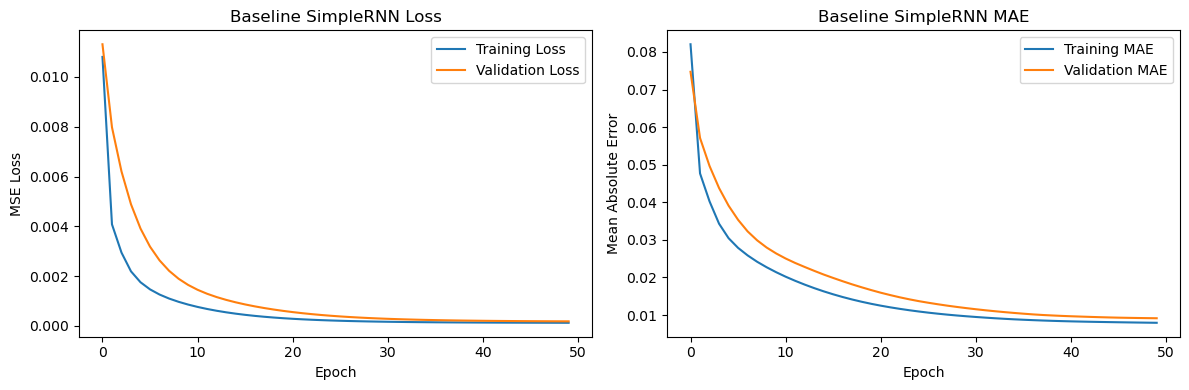

In [13]:
# Visualize SimpleRNN training performance

plot_training_curves(
    simple_rnn_history,
    "Baseline SimpleRNN"
)

Evaluation on test data


 1/25 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step



1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


Baseline SimpleRNN Train RMSE: 493.52
Baseline SimpleRNN Test RMSE: 3953.11
Baseline SimpleRNN Train MAE: 364.83
Baseline SimpleRNN Test MAE: 2409.82


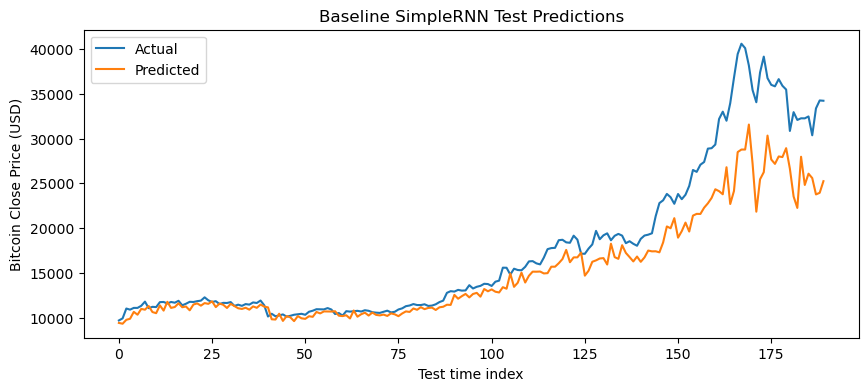

In [14]:
# Evaluate SimpleRNN on held-out future test data

evaluate_and_plot(
    simple_rnn_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline SimpleRNN"
)

### Baseline LSTM Model

In [15]:
# Build and train baseline LSTM model

lstm_model = Sequential([
    LSTM(
        8,                                     # small baseline LSTM layer
        activation="tanh",                     # standard LSTM hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

lstm_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

lstm_history = lstm_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 1/40 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - loss: 0.0031 - mean_absolute_error: 0.0546


29/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014 - mean_absolute_error: 0.0300


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0018 - mean_absolute_error: 0.0332 - val_loss: 0.0052 - val_mean_absolute_error: 0.0536


...


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4289e-04 - mean_absolute_error: 0.0086 - val_loss: 2.1267e-04 - val_mean_absolute_error: 0.0094


Epoch 50/50



 1/40 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.8311e-05 - mean_absolute_error: 0.0071


28/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.9523e-05 - mean_absolute_error: 0.0068 


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4151e-04 - mean_absolute_error: 0.0086 - val_loss: 2.1150e-04 - val_mean_absolute_error: 0.0094


Visualizing training

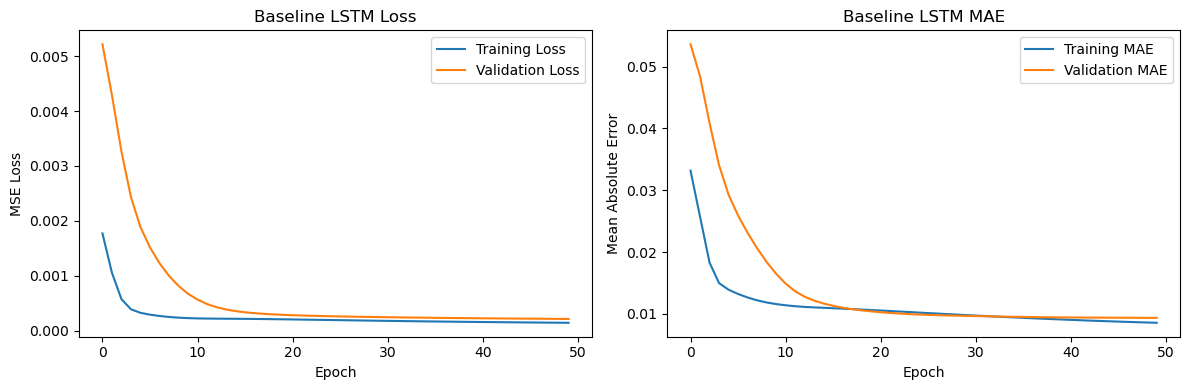

In [16]:
# Visualize LSTM training performance

plot_training_curves(
    lstm_history,
    "Baseline LSTM"
)

Evaluation on test data


 1/25 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step



1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


Baseline LSTM Train RMSE: 434.39
Baseline LSTM Test RMSE: 2398.13
Baseline LSTM Train MAE: 299.69
Baseline LSTM Test MAE: 1580.11


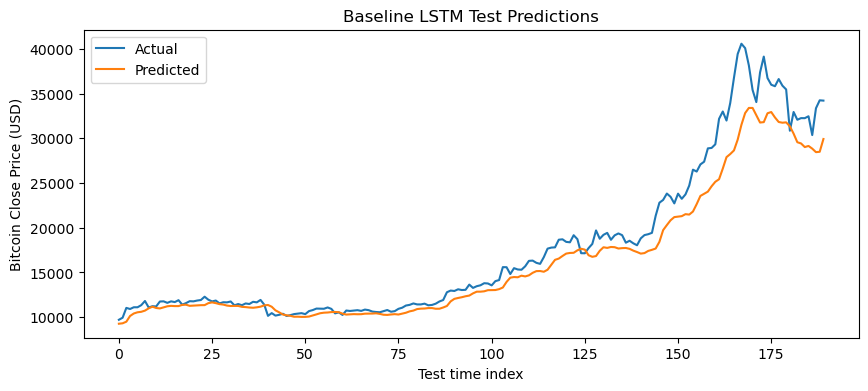

In [17]:
# Evaluate LSTM on held-out future test data

evaluate_and_plot(
    lstm_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline LSTM"
)

### Baseline GRU model

In [18]:
# Build and train baseline GRU model

gru_model = Sequential([
    GRU(
        8,                                      # intentionally small baseline GRU layer
        activation="tanh",                     # standard GRU hidden-state activation
        input_shape=(look_back, trainX_bitcoin.shape[2])
    ),                                         # input shape = timesteps, features

    Dense(1)                                   # output layer: predict next close_USD value
])

gru_model.compile(
    optimizer="adam",                          # adaptive gradient-based optimizer
    loss="mean_squared_error",                 # regression loss
    metrics=["mean_absolute_error"]            # easier-to-interpret training metric
)

gru_history = gru_model.fit(
    trainX_bitcoin,
    trainY_bitcoin,
    epochs=50,                                 # baseline training limit
    batch_size=16,                             # update weights after each batch
    validation_split=0.2,                      # last 20% of training data used for validation
    shuffle=False,                             # preserve chronological order
    verbose=1
)

Epoch 1/50


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 1/40 ━━━━━━━━━━━━━━━━━━━━ 1:06 2s/step - loss: 0.0248 - mean_absolute_error: 0.1565


18/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0094 - mean_absolute_error: 0.0831 


39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0069 - mean_absolute_error: 0.0700

...


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3539e-04 - mean_absolute_error: 0.0088 - val_loss: 2.7829e-04 - val_mean_absolute_error: 0.0141


Epoch 50/50



 1/40 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.9993e-04 - mean_absolute_error: 0.0130


23/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.4657e-05 - mean_absolute_error: 0.0072 


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3481e-04 - mean_absolute_error: 0.0088 - val_loss: 2.7734e-04 - val_mean_absolute_error: 0.0141


Visualizing training

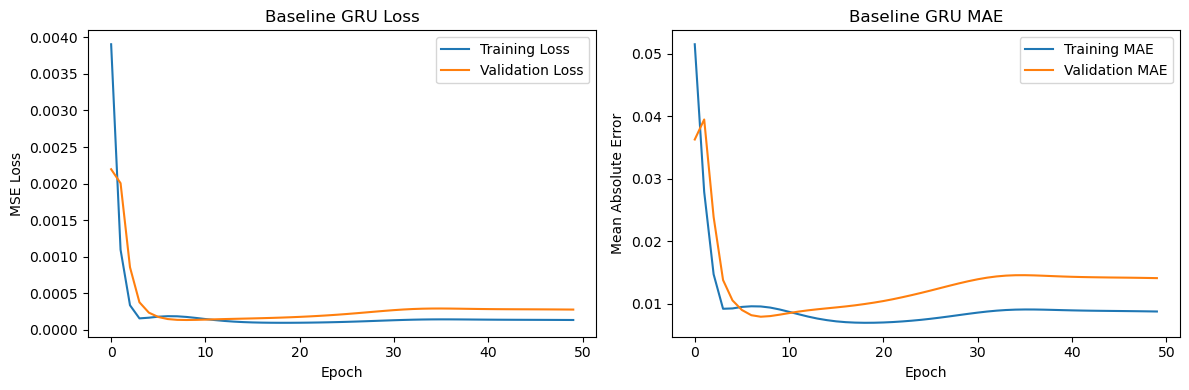

In [19]:
# Visualize GRU training performance

plot_training_curves(
    gru_history,
    "Baseline GRU"
)

Evaluation on test data


 1/25 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step



1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


Baseline GRU Train RMSE: 560.80
Baseline GRU Test RMSE: 4732.63
Baseline GRU Train MAE: 438.16
Baseline GRU Test MAE: 3248.33


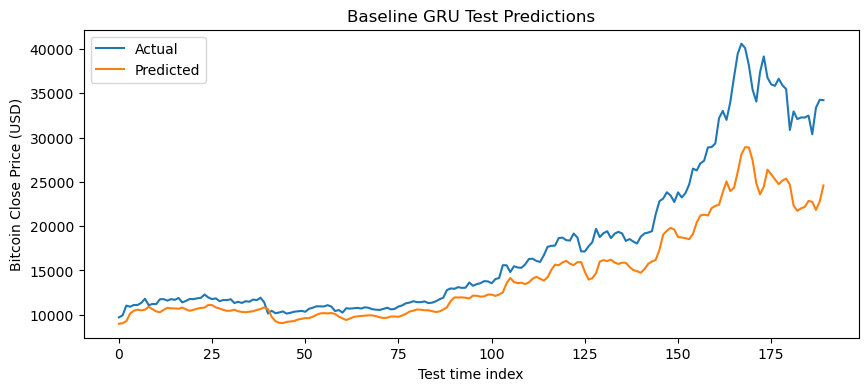

In [20]:
# Evaluate GRU on held-out future test data

evaluate_and_plot(
    gru_model,
    trainX_bitcoin,
    testX_bitcoin,
    trainY_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index,
    "Baseline GRU"
)

### Activity: Improving Forecasting Models

Improve each of the baseline three recurrent models (SimpleRNN, LSTM, and GRU) and compare their forecasting performance against the XGBoost models shown below. You should provide the code for each improved model and include a markdown cell after each model describing what you changed, what you explored, and how the changes affected performance. After completing your experiments, provide a short overall summary discussing which approaches appeared most effective, which models were easiest or hardest to tune, and what tradeoffs you observed between model complexity, training stability, and forecasting performance.

Train-only scaled test close max: 3.78
Full-data scaled test close max: 1.0


Epoch 1/80


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 1/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 0.0363 - mean_absolute_error: 0.1871


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0052 - mean_absolute_error: 0.0513 - val_loss: 0.0018 - val_mean_absolute_error: 0.0278


...


 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.2757e-05 - mean_absolute_error: 0.0071


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3206e-04 - mean_absolute_error: 0.0080 - val_loss: 2.2341e-04 - val_mean_absolute_error: 0.0117


Epoch 54/80



 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3295e-04 - mean_absolute_error: 0.0089


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4116e-04 - mean_absolute_error: 0.0085 - val_loss: 1.8956e-04 - val_mean_absolute_error: 0.0102


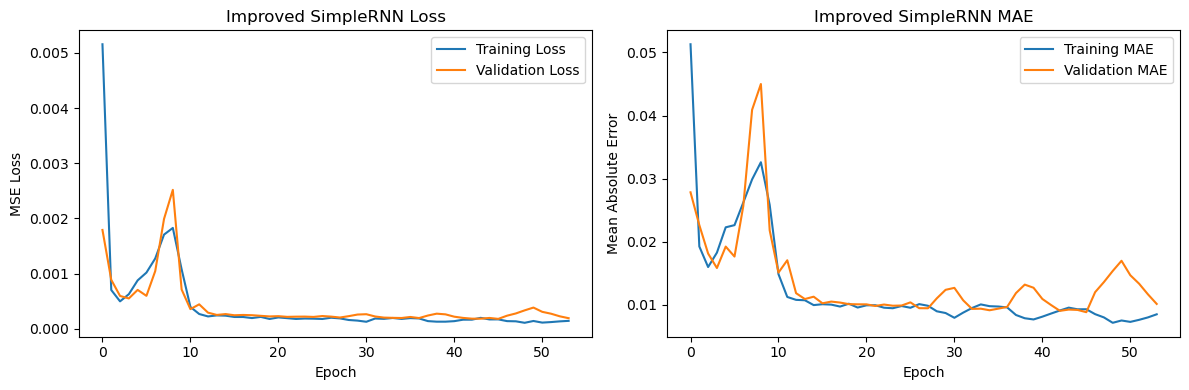


 1/25 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step



1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Improved SimpleRNN Train RMSE: 404.84
Improved SimpleRNN Test RMSE: 1935.74
Improved SimpleRNN Train MAE: 279.39
Improved SimpleRNN Test MAE: 1169.11


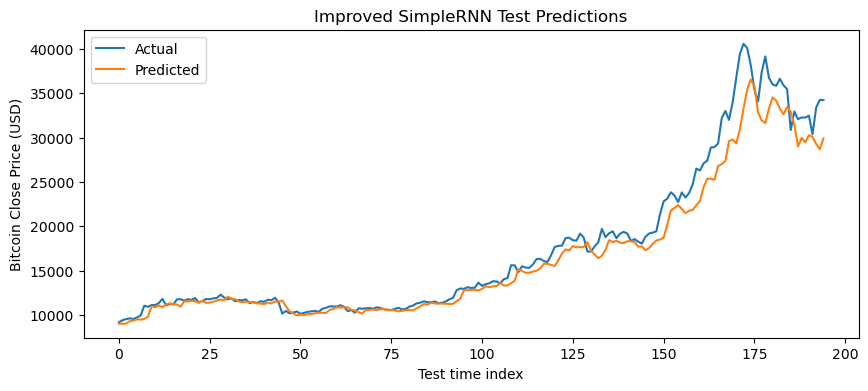


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Improved SimpleRNN Test RMSE: 1935.74
Improved SimpleRNN Test MAE: 1169.11


In [21]:
# Improved SimpleRNN model

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Check the effect of train-only scaling on the held-out price range
train_only_scaler = MinMaxScaler(feature_range=(0, 1))
train_only_scaled = train_only_scaler.fit_transform(
    bitcoin_model[features].iloc[:train_size]
)

train_only_test_scaled = train_only_scaler.transform(
    bitcoin_model[features].iloc[train_size:]
)

print(
    "Train-only scaled test close max:",
    train_only_test_scaled[:, target_index].max().round(2)
)

print(
    "Full-data scaled test close max:",
    test_bitcoin[:, target_index].max().round(2)
)

simple_rnn_look_back = 5

simple_trainX, simple_trainY = create_sequences(
    train_bitcoin,
    target_index,
    simple_rnn_look_back
)

simple_testX, simple_testY = create_sequences(
    test_bitcoin,
    target_index,
    simple_rnn_look_back
)

simple_rnn_callback = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

improved_simple_rnn_model = Sequential([
    SimpleRNN(
        48,                                    # larger recurrent layer
        activation="tanh",
        dropout=0.10,                         # regularize the recurrent model
        input_shape=(simple_rnn_look_back, simple_trainX.shape[2])
    ),

    Dense(
        16,
        activation="relu"
    ),                                        # small nonlinear layer before output

    Dense(1)
])

improved_simple_rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

improved_simple_rnn_history = improved_simple_rnn_model.fit(
    simple_trainX,
    simple_trainY,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[simple_rnn_callback],
    verbose=1
)

plot_training_curves(
    improved_simple_rnn_history,
    "Improved SimpleRNN"
)

evaluate_and_plot(
    improved_simple_rnn_model,
    simple_trainX,
    simple_testX,
    simple_trainY,
    simple_testY,
    scaler_bitcoin,
    target_index,
    "Improved SimpleRNN"
)

improved_simple_rnn_rmse, improved_simple_rnn_mae = evaluate_metrics(
    improved_simple_rnn_model,
    simple_testX,
    simple_testY,
    scaler_bitcoin,
    target_index
)

print(f"Improved SimpleRNN Test RMSE: {improved_simple_rnn_rmse:.2f}")
print(f"Improved SimpleRNN Test MAE: {improved_simple_rnn_mae:.2f}")

The SimpleRNN used a shorter 5 day window.

I increased the recurrent units from 8 to 48.

I added dropout and a small dense layer.

Train-only scaling pushed the test close maximum to 3.78.

The improved SimpleRNN test RMSE was 1935.74.

The baseline SimpleRNN test RMSE was 3953.11.

Epoch 1/80


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 1/20 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - loss: 0.0207 - mean_absolute_error: 0.1422


11/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102 - mean_absolute_error: 0.0895


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0035 - mean_absolute_error: 0.0468 - val_loss: 0.0011 - val_mean_absolute_error: 0.0263


...


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8502e-04 - mean_absolute_error: 0.0090 - val_loss: 3.1783e-04 - val_mean_absolute_error: 0.0146


Epoch 26/80



 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.5096e-04 - mean_absolute_error: 0.0093


11/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1438e-04 - mean_absolute_error: 0.0080 


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2946e-04 - mean_absolute_error: 0.0100 - val_loss: 2.8587e-04 - val_mean_absolute_error: 0.0136


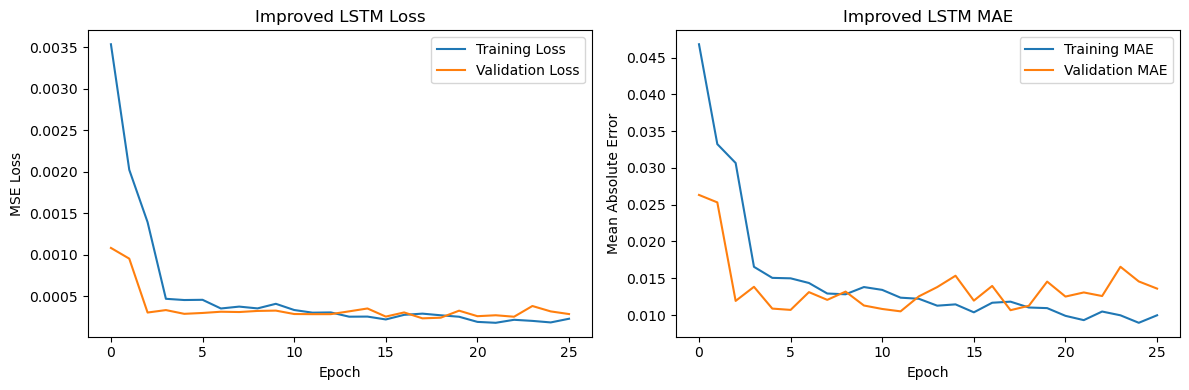


 1/25 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step



1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


Improved LSTM Train RMSE: 497.16
Improved LSTM Test RMSE: 2167.71
Improved LSTM Train MAE: 353.09
Improved LSTM Test MAE: 1428.63


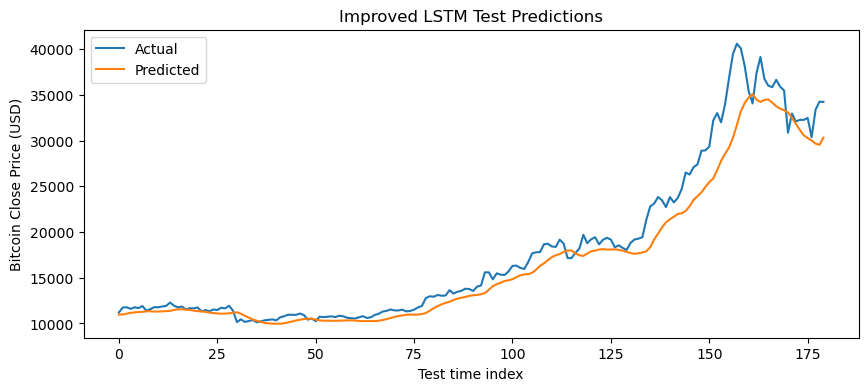


1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


Improved LSTM Test RMSE: 2167.71
Improved LSTM Test MAE: 1428.63


In [22]:
# Improved LSTM model

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

lstm_look_back = 20

lstm_trainX, lstm_trainY = create_sequences(
    train_bitcoin,
    target_index,
    lstm_look_back
)

lstm_testX, lstm_testY = create_sequences(
    test_bitcoin,
    target_index,
    lstm_look_back
)

lstm_callback = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

improved_lstm_model = Sequential([
    LSTM(
        64,                                    # larger memory layer
        activation="tanh",
        dropout=0.10,                         # reduce overfitting
        input_shape=(lstm_look_back, lstm_trainX.shape[2])
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(1)
])

improved_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

improved_lstm_history = improved_lstm_model.fit(
    lstm_trainX,
    lstm_trainY,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[lstm_callback],
    verbose=1
)

plot_training_curves(
    improved_lstm_history,
    "Improved LSTM"
)

evaluate_and_plot(
    improved_lstm_model,
    lstm_trainX,
    lstm_testX,
    lstm_trainY,
    lstm_testY,
    scaler_bitcoin,
    target_index,
    "Improved LSTM"
)

improved_lstm_rmse, improved_lstm_mae = evaluate_metrics(
    improved_lstm_model,
    lstm_testX,
    lstm_testY,
    scaler_bitcoin,
    target_index
)

print(f"Improved LSTM Test RMSE: {improved_lstm_rmse:.2f}")
print(f"Improved LSTM Test MAE: {improved_lstm_mae:.2f}")

The LSTM used a 20 day lookback window.

I increased the hidden units from 8 to 64.

Dropout and early stopping made training more stable.

The improved LSTM test RMSE was 2167.71.

The baseline LSTM test RMSE was 2398.13.

Epoch 1/80


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 1/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - loss: 0.0038 - mean_absolute_error: 0.0574


10/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - mean_absolute_error: 0.0399


19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - mean_absolute_error: 0.0385

...

Epoch 10/80



 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.6861e-04 - mean_absolute_error: 0.0140


 9/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.8687e-04 - mean_absolute_error: 0.0109 


17/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.9915e-04 - mean_absolute_error: 0.0126


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.8000e-04 - mean_absolute_error: 0.0177 - val_loss: 6.6555e-04 - val_mean_absolute_error: 0.0213


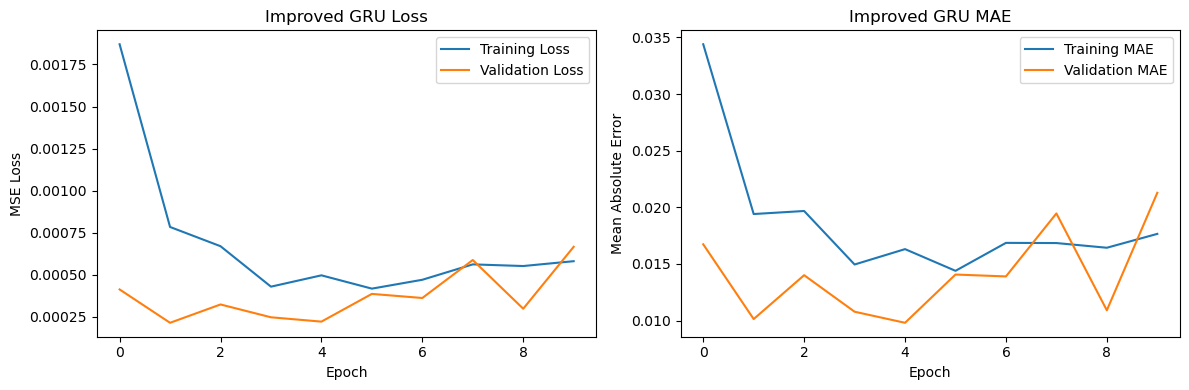


 1/25 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step



1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


Improved GRU Train RMSE: 544.74
Improved GRU Test RMSE: 1709.60
Improved GRU Train MAE: 443.34
Improved GRU Test MAE: 992.41


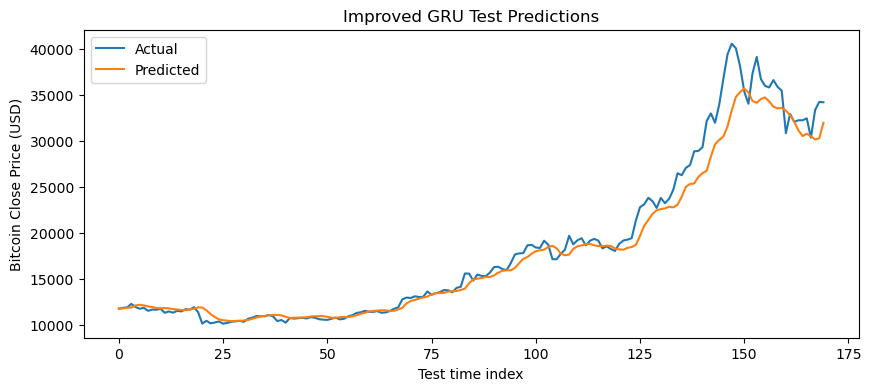


1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


Improved GRU Test RMSE: 1709.60
Improved GRU Test MAE: 992.41


In [23]:
# Improved GRU model

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

gru_look_back = 30

gru_trainX, gru_trainY = create_sequences(
    train_bitcoin,
    target_index,
    gru_look_back
)

gru_testX, gru_testY = create_sequences(
    test_bitcoin,
    target_index,
    gru_look_back
)

gru_callback = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

improved_gru_model = Sequential([
    GRU(
        32,                                    # compact gated recurrent layer
        activation="tanh",
        dropout=0.10,
        input_shape=(gru_look_back, gru_trainX.shape[2])
    ),

    Dense(
        8,
        activation="relu"
    ),

    Dense(1)
])

improved_gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

improved_gru_history = improved_gru_model.fit(
    gru_trainX,
    gru_trainY,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[gru_callback],
    verbose=1
)

plot_training_curves(
    improved_gru_history,
    "Improved GRU"
)

evaluate_and_plot(
    improved_gru_model,
    gru_trainX,
    gru_testX,
    gru_trainY,
    gru_testY,
    scaler_bitcoin,
    target_index,
    "Improved GRU"
)

improved_gru_rmse, improved_gru_mae = evaluate_metrics(
    improved_gru_model,
    gru_testX,
    gru_testY,
    scaler_bitcoin,
    target_index
)

print(f"Improved GRU Test RMSE: {improved_gru_rmse:.2f}")
print(f"Improved GRU Test MAE: {improved_gru_mae:.2f}")

The GRU used a 30 day lookback window.

I used more units than the baseline but kept the model smaller than the LSTM.

Dropout and early stopping reduced overfitting.

The improved GRU test RMSE was 1709.60.

The baseline GRU test RMSE was 4732.63.

### Your summary

The return-based XGBoost model was best overall.

Its test RMSE was 925.44.

The improved GRU was the best recurrent model.

Its test RMSE was 1709.60.

The SimpleRNN improved with a shorter window and more units.

The LSTM was the hardest recurrent model to tune.

Train-only scaling made the test range harder for recurrent models.

Dropout and early stopping improved stability.

Larger models took longer to train.

_______________________________________________________________________________________________________________________________

_______________________________________________________________________________________________________________________________

### Do you need RNN for time series data?

#### XGB with lagged features

Plotting function for nonscaled models

In [24]:
# Generic prediction plotting function for models already on the original scale

def plot_predictions(actual, predicted, title):

    plt.figure(figsize=(10, 4))

    plt.plot(actual, label="Actual")
    plt.plot(predicted, label="Predicted")

    plt.title(title)
    plt.xlabel("Test time index")
    plt.ylabel("Bitcoin Close Price (USD)")

    plt.ticklabel_format(style="plain", axis="y")

    plt.legend()
    plt.show()

XGB Data preparation

In [25]:
# Create lagged features for XGBoost

xgb_data = bitcoin[["date"] + features].copy()

lag_days = 10

for lag in range(1, lag_days + 1):
    for col in features:
        xgb_data[f"{col}_lag{lag}"] = xgb_data[col].shift(lag)

xgb_data["target_close_USD"] = xgb_data["close_USD"]

xgb_data = xgb_data.dropna().reset_index(drop=True)

xgb_data.head()

,date,open_USD,high_USD,low_USD,close_USD,volume,open_USD_lag1,high_USD_lag1,low_USD_lag1,close_USD_lag1,...,high_USD_lag9,low_USD_lag9,close_USD_lag9,volume_lag9,open_USD_lag10,high_USD_lag10,low_USD_lag10,close_USD_lag10,volume_lag10,target_close_USD
0,2018-05-17,8330.00,8464.00,7979.00,8041.46,25439,8462.00,8488.00,8083.01,8330.00,...,9475.70,9060.54,9187.56,25533.0,9661.02,9689.67,9181.00,9365.00,33787.0,8041.46
1,2018-05-18,8038.82,8273.21,7911.90,8239.81,23476,8330.00,8464.00,7979.00,8041.46,...,9390.00,8965.00,9310.00,25673.0,9365.00,9475.70,9060.54,9187.56,25533.0,8239.81
2,2018-05-19,8238.01,8390.80,8095.73,8233.49,17193,8038.82,8273.21,7911.90,8239.81,...,9395.12,8970.00,9002.20,25055.0,9178.00,9390.00,8965.00,9310.00,25673.0,8233.49
3,2018-05-20,8233.49,8609.00,8163.90,8526.98,19957,8238.01,8390.80,8095.73,8233.49,...,9016.80,8341.00,8400.00,48227.0,9310.00,9395.12,8970.00,9002.20,25055.0,8526.98
4,2018-05-21,8526.97,8595.31,8305.00,8381.24,21516,8233.49,8609.00,8163.90,8526.98,...,8646.88,8153.00,8465.94,40241.0,9002.21,9016.80,8341.00,8400.00,48227.0,8381.24


XGB train test preparation

In [26]:
# Prepare XGBoost train/test data

xgb_features = [
    col for col in xgb_data.columns
    if "lag" in col
]

X_xgb = xgb_data[xgb_features]
y_xgb = xgb_data["target_close_USD"]

train_size_xgb = int(len(xgb_data) * 0.8)

trainX_xgb = X_xgb.iloc[:train_size_xgb]
testX_xgb = X_xgb.iloc[train_size_xgb:]

trainY_xgb = y_xgb.iloc[:train_size_xgb]
testY_xgb = y_xgb.iloc[train_size_xgb:]

print("trainX_xgb shape:", trainX_xgb.shape)
print("testX_xgb shape:", testX_xgb.shape)
print("trainY_xgb shape:", trainY_xgb.shape)
print("testY_xgb shape:", testY_xgb.shape)

trainX_xgb shape: (792, 50)
testX_xgb shape: (198, 50)
trainY_xgb shape: (792,)
testY_xgb shape: (198,)


Build & train model

In [27]:
# Build and train baseline XGBoost model

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    trainX_xgb,
    trainY_xgb
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluating on test data

In [28]:
# Evaluate XGBoost baseline on held-out future test data

xgb_test_pred = xgb_model.predict(testX_xgb)

xgb_rmse = np.sqrt(mean_squared_error(testY_xgb, xgb_test_pred))
xgb_mae = mean_absolute_error(testY_xgb, xgb_test_pred)

print(f"Baseline XGBoost Test RMSE: {xgb_rmse:.2f}")
print(f"Baseline XGBoost Test MAE: {xgb_mae:.2f}")

Baseline XGBoost Test RMSE: 10490.81
Baseline XGBoost Test MAE: 6340.83


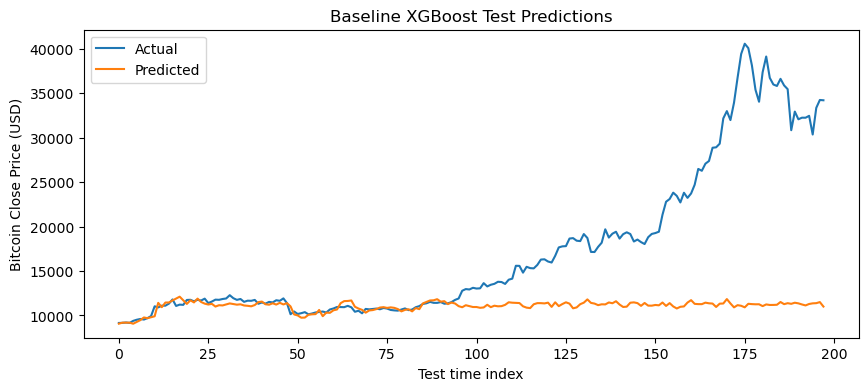

In [29]:
# Visualize baselineXGBoost predictions

plot_predictions(
    testY_xgb.values,
    xgb_test_pred,
    "Baseline XGBoost Test Predictions"
)

Modifying the XGB target to percent change instead of raw price

Improved XGBoost Test RMSE: 925.44
Improved XGBoost Test MAE: 564.97


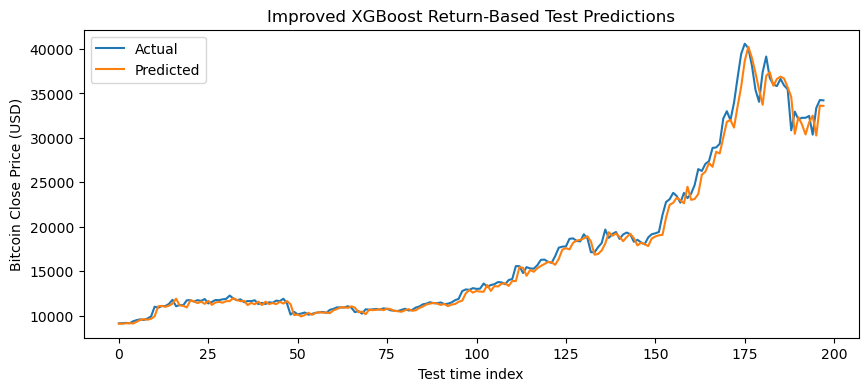

In [30]:
# Improved XGBoost: predict next-day percent change instead of raw price

xgb_return_data = bitcoin[["date"] + features].copy()

xgb_return_data["close_return"] = (
    xgb_return_data["close_USD"]
    .pct_change()
)                                                               # calculate daily percent return

lag_days = 10                                                   # use previous 10 days as predictors

for lag in range(1, lag_days + 1):

    for col in features:
        xgb_return_data[f"{col}_lag{lag}"] = (
            xgb_return_data[col]
            .shift(lag)
        )                                                       # previous feature values become lag predictors

    xgb_return_data[f"close_return_lag{lag}"] = (
        xgb_return_data["close_return"]
        .shift(lag)
    )                                                           # include lagged returns as predictors

xgb_return_data["target_return"] = (
    xgb_return_data["close_return"]
    .shift(-1)
)                                                               # predict next-day return

xgb_return_data["current_close_USD"] = (
    xgb_return_data["close_USD"]
)                                                               # keep current close price for reconstruction later

xgb_return_data = (
    xgb_return_data
    .dropna()
    .reset_index(drop=True)
)                                                               # remove rows without sufficient lag history

xgb_return_features = [
    col for col in xgb_return_data.columns
    if "lag" in col
]                                                               # use lagged values as predictors

X_xgb_return = xgb_return_data[xgb_return_features]
y_xgb_return = xgb_return_data["target_return"]

train_size_xgb_return = int(len(xgb_return_data) * 0.8)        # chronological 80/20 split

trainX_xgb_return = X_xgb_return.iloc[:train_size_xgb_return]
testX_xgb_return = X_xgb_return.iloc[train_size_xgb_return:]

trainY_xgb_return = y_xgb_return.iloc[:train_size_xgb_return]
testY_xgb_return = y_xgb_return.iloc[train_size_xgb_return:]

test_current_close = (
    xgb_return_data["current_close_USD"]
    .iloc[train_size_xgb_return:]
)                                                               # current price used to reconstruct next-day prediction

xgb_return_model = XGBRegressor(
    n_estimators=300,                                           # more trees for stronger learning
    max_depth=2,                                                # shallow trees reduce overfitting
    learning_rate=0.03,                                         # smaller learning steps
    subsample=0.8,                                              # random row sampling
    colsample_bytree=0.8,                                       # random feature sampling
    objective="reg:squarederror",
    random_state=42
)

xgb_return_model.fit(
    trainX_xgb_return,
    trainY_xgb_return
)

xgb_return_pred = xgb_return_model.predict(
    testX_xgb_return
)                                                               # predict next-day percent return

xgb_return_price_pred = (
    test_current_close.values * (1 + xgb_return_pred)
)                                                               # convert predicted return back to predicted price

xgb_return_price_actual = (
    test_current_close.values * (1 + testY_xgb_return.values)
)                                                               # actual next-day price

xgb_return_rmse = np.sqrt(
    mean_squared_error(
        xgb_return_price_actual,
        xgb_return_price_pred
    )
)

xgb_return_mae = mean_absolute_error(
    xgb_return_price_actual,
    xgb_return_price_pred
)

print(f"Improved XGBoost Test RMSE: {xgb_return_rmse:.2f}")
print(f"Improved XGBoost Test MAE: {xgb_return_mae:.2f}")

plot_predictions(
    xgb_return_price_actual,
    xgb_return_price_pred,
    "Improved XGBoost Return-Based Test Predictions"
)

In [31]:
# Compare baseline model performance

simple_rnn_rmse, simple_rnn_mae = evaluate_metrics(
    simple_rnn_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

lstm_rmse, lstm_mae = evaluate_metrics(
    lstm_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

gru_rmse, gru_mae = evaluate_metrics(
    gru_model,
    testX_bitcoin,
    testY_bitcoin,
    scaler_bitcoin,
    target_index
)

model_comparison = pd.DataFrame({
    "Model": [
        "SimpleRNN",
        "LSTM",
        "GRU",
        "XGBoost raw price target",
        "XGBoost return target"
    ],

    "RMSE": [
        simple_rnn_rmse,
        lstm_rmse,
        gru_rmse,
        xgb_rmse,
        xgb_return_rmse
    ],

    "MAE": [
        simple_rnn_mae,
        lstm_mae,
        gru_mae,
        xgb_mae,
        xgb_return_mae
    ]
})

model_comparison.sort_values("RMSE")


1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step



1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step



1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


,Model,RMSE,MAE
4,XGBoost return target,925.441209,564.967019
1,LSTM,2398.133694,1580.107556
0,SimpleRNN,3953.111578,2409.817394
2,GRU,4732.625074,3248.330800
3,XGBoost raw price target,10490.806519,6340.832358
